In [34]:
import numpy as np
import pandas as pd
import os
import sys
#import fileinput

In [35]:
#remove temporary file if it exists
filePath = 'temporary_df.txt'
if os.path.exists(filePath):
    os.remove(filePath)
else:
    None

In [36]:
 # will be used to write teh output file
site='Paranal'
prod='PROD6'

In [37]:
# !pwd
# !ls

In [38]:
temp = open(filePath,"w")
temp.write("object_class pos_x pos_y pos_z sphere_radius tel_id telescope_name class_id geo_code")
temp.write("\n")
with open( f'/Users/macbook/divtel/INPUTS_CTA_PROD6-array-Paranal-alpha.inc', 'r') as f:
    for line in f:
        # Use continue so your code doesn't become a nested mess.
        if line[0] == '*':
            continue  
        # if this check passes, we can assume line is not a comment.
        else: 
            line=line.replace('(',' ')            
            line=line.replace(')',' ')
            line=line.replace('#',' ')
            line = " ".join(line.split())
            temp.write(f'{line}\n')
            

temp.close()

In [39]:
df = pd.read_csv('temporary_df.txt', header=0, sep=' ', engine='python')
# removing my temporary file
os.remove(filePath)

In [40]:
df = df.iloc[1:].reset_index(drop=True)
df

,object_class,pos_x,pos_y,pos_z,sphere_radius,tel_id,telescope_name,class_id,geo_code
0,TELESCOPE,0.00E2,0.0,2400.0,915.0,ID=5,MSTS,1.0,A0A
1,TELESCOPE,1.45E2,15107.0,2500.0,915.0,ID=6,MSTS,2.0,A4A
2,TELESCOPE,-1.45E2,-15107.0,3100.0,915.0,ID=7,MSTS,3.0,A3A
3,TELESCOPE,150.79E2,7360.0,2100.0,915.0,ID=8,MSTS,4.0,C2A
4,TELESCOPE,149.35E2,-7648.0,2600.0,915.0,ID=9,MSTS,5.0,C1A
5,TELESCOPE,152.38E2,23867.0,2400.0,915.0,ID=10,MSTS,6.0,C4A
6,TELESCOPE,147.77E2,-24155.0,3000.0,915.0,ID=11,MSTS,7.0,C3A
7,TELESCOPE,313.15E2,-300.0,1900.0,915.0,ID=12,MSTS,8.0,F0A
8,TELESCOPE,-150.79E2,-7359.0,2800.0,915.0,ID=13,MSTS,9.0,X1A
9,TELESCOPE,-149.35E2,7648.0,2800.0,915.0,ID=14,MSTS,10.0,X2A


In [41]:
for c in ["pos_x", "pos_y", "pos_z"]:
    df[c] = pd.to_numeric(df[c], errors="coerce") * 1e-2  # cm → m

# optional: sphere radius too
# df["sphere_radius_m"] = pd.to_numeric(df["sphere_radius"], errors="coerce") * 1e-2

print(df[["pos_x","pos_y","pos_z"]].head())


    pos_x   pos_y  pos_z
0    0.00    0.00   24.0
1    1.45  151.07   25.0
2   -1.45 -151.07   31.0
3  150.79   73.60   21.0
4  149.35  -76.48   26.0


In [42]:
df

,object_class,pos_x,pos_y,pos_z,sphere_radius,tel_id,telescope_name,class_id,geo_code
0,TELESCOPE,0.00,0.00,24.0,915.0,ID=5,MSTS,1.0,A0A
1,TELESCOPE,1.45,151.07,25.0,915.0,ID=6,MSTS,2.0,A4A
2,TELESCOPE,-1.45,-151.07,31.0,915.0,ID=7,MSTS,3.0,A3A
3,TELESCOPE,150.79,73.60,21.0,915.0,ID=8,MSTS,4.0,C2A
4,TELESCOPE,149.35,-76.48,26.0,915.0,ID=9,MSTS,5.0,C1A
5,TELESCOPE,152.38,238.67,24.0,915.0,ID=10,MSTS,6.0,C4A
6,TELESCOPE,147.77,-241.55,30.0,915.0,ID=11,MSTS,7.0,C3A
7,TELESCOPE,313.15,-3.00,19.0,915.0,ID=12,MSTS,8.0,F0A
8,TELESCOPE,-150.79,-73.59,28.0,915.0,ID=13,MSTS,9.0,X1A
9,TELESCOPE,-149.35,76.48,28.0,915.0,ID=14,MSTS,10.0,X2A


In [43]:
#cm to m conversion
# df.pos_x=df['pos_x'].apply(lambda x: x*10**(-2))
# df.pos_y=df['pos_y'].apply(lambda x: x*10**(-2))
# df.pos_z=df['pos_z'].apply(lambda x: x*10**(-2))
# df.sphere_radius=df['sphere_radius'].apply(lambda x: x*10**(-2))
# df

In [44]:
with open(fileName, 'a+') as output:
    for i in range(len(df.telescope_name)):
        # skip non-telescopes or missing names
        if df.object_class[i] != 'TELESCOPE' or pd.isna(df.telescope_name[i]):
            continue
        name = str(df.telescope_name[i])

        if 'LST' in name:
            focal_lenght = 28; camera_radius = 2.15
        elif 'MST' in name:
            focal_lenght = 16; camera_radius = 3.85
        elif 'SST' in name:
            focal_lenght = 5.6; camera_radius = 4.45
        else:
            continue

        line = f"{round(df.pos_x[i],2)} {round(df.pos_y[i],2)} {round(df.pos_z[i],2)} {focal_lenght} {camera_radius}"
        output.write(line + "\n")

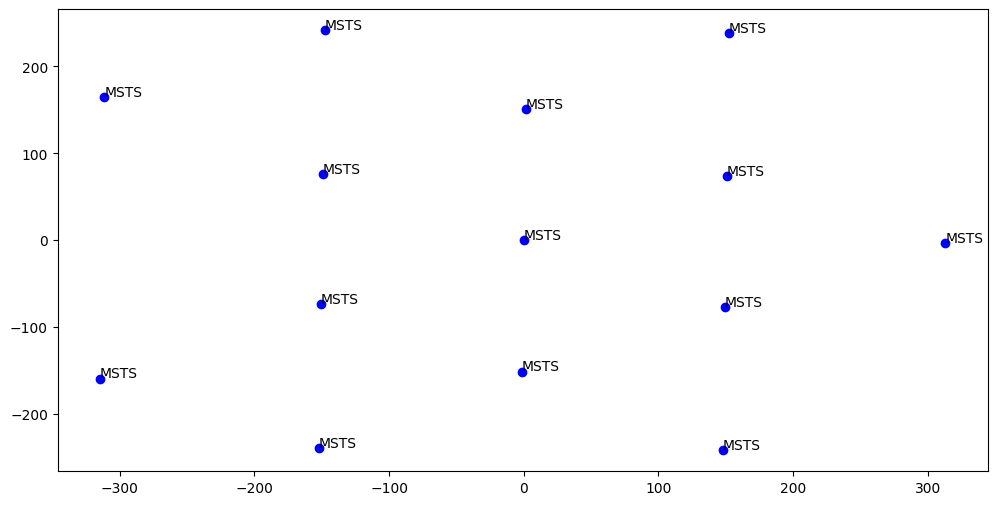

In [45]:
import matplotlib.pyplot as plt
fig = plt.subplots(figsize=(12,6))
for i,tel in enumerate(df.telescope_name):
    if df.object_class[i] != 'TELESCOPE' or pd.isna(df.telescope_name[i]):
            continue
    plt.annotate(tel,(df.pos_x[i],df.pos_y[i]+1))
    if 'LST' in tel: 
        plt.scatter(df.pos_x[i],df.pos_y[i],color='orange')
    elif 'SST' in tel: 
        plt.scatter(df.pos_x[i],df.pos_y[i],color='green')
    else:
        plt.scatter(df.pos_x[i],df.pos_y[i],color='blue')

